## Imports

In [2]:
import mesmer
import model
import model_analysis

import importlib
import matplotlib.pyplot as plt
import xarray as xr

import numpy as np

import cartopy.crs as ccrs

from scipy.stats import(
    beta
)



### Updates (temp)

In [3]:
importlib.reload(model.stats);
importlib.reload(model.shape_data);
importlib.reload(model.transform);



## Load Data

In [4]:
is_local_data = False
month_idx = 4
safe = False

In [5]:
mrsol_ds_for_mean = model.shape_data.load_data_set(var = "mrsol", local = is_local_data, run_idx=1)

mrsol_ds_for_var = model.shape_data.load_data_set(var = "mrsol", local = is_local_data, run_idx=2)

#Wenn man sicher gehen will, das der Predictor die testdaten nicht kennen soll, kann man die testdaten auch erst nach dem Calibrieren berechnen
mrsol_ds_for_test = model.shape_data.load_data_set(var = "mrsol", local = is_local_data, run_idx=3)


In [6]:
mrsol_empirical_maximas = mrsol_ds_for_mean.max("time")

mrsol_approx_1_maximas = mrsol_empirical_maximas.copy(deep=True)
mrsol_approx_1_maximas["mrsol"] = mrsol_empirical_maximas["mrsol"] * 1.1 + 1e-5

mrsol_approx_2_maximas = mrsol_empirical_maximas.copy(deep=True)
mrsol_approx_2_maximas["mrsol"] = np.maximum(mrsol_empirical_maximas["mrsol"] * 1.05,(mrsol_empirical_maximas["depth_bnds"].isel(bnds=1)-mrsol_empirical_maximas["depth_bnds"].isel(bnds=0))*1000*0.30)

mrsol_month_empirical_maximas = model.shape_data.prune_group_ds_timespan(mrsol_ds_for_mean,Month_idx=month_idx).max("time")
mrsol_month_empirical_maximas["mrsol"] = mrsol_month_empirical_maximas["mrsol"] * 1.1 + 1e-5



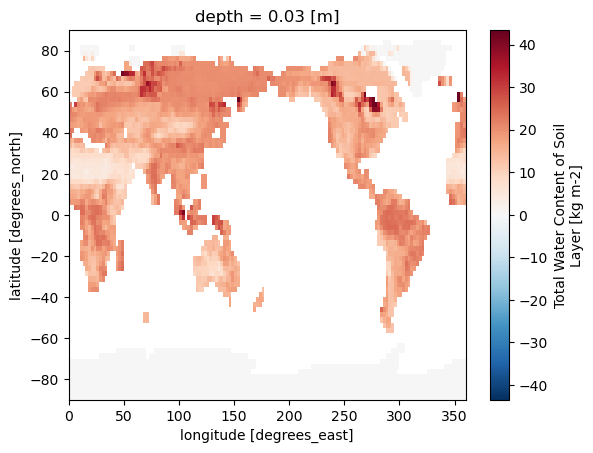

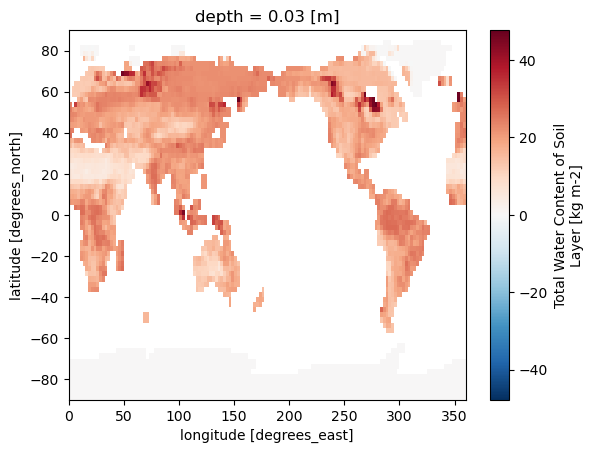

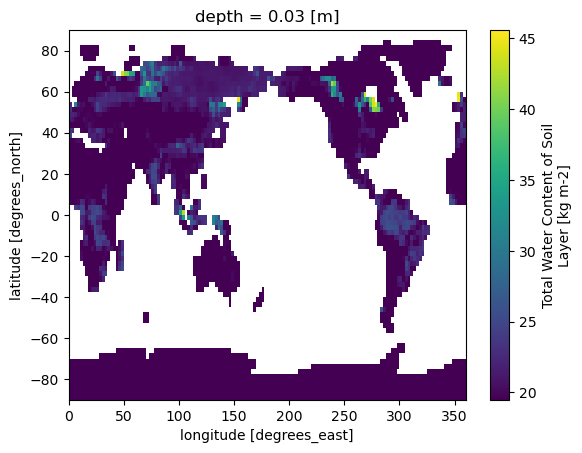

In [7]:
mrsol_empirical_maximas.isel(depth = 0).mrsol.plot(x="lon")
plt.show()
mrsol_approx_1_maximas.isel(depth = 0).mrsol.plot(x="lon")
plt.show()
mrsol_approx_2_maximas.isel(depth = 0).mrsol.plot(x="lon");
plt.show()
mrsol_maximas = mrsol_approx_1_maximas

In [8]:
mrsol_relative_ds_for_mean = mrsol_ds_for_mean.copy(deep=True)
mrsol_relative_ds_for_mean["mrsol"] = mrsol_relative_ds_for_mean["mrsol"]/mrsol_maximas["mrsol"]

mrsol_relative_ds_for_var = mrsol_ds_for_var.copy(deep=True)
mrsol_relative_ds_for_var["mrsol"] = mrsol_relative_ds_for_var["mrsol"]/mrsol_maximas["mrsol"]

mrsol_relative_ds_for_test = mrsol_ds_for_test.copy(deep=True)
mrsol_relative_ds_for_test["mrsol"] = mrsol_relative_ds_for_test["mrsol"]/mrsol_maximas["mrsol"]

In [9]:
mrsol_pruned_ds_for_mean = model.shape_data.prune_group_ds_timespan(mrsol_relative_ds_for_mean,Month_idx=month_idx)
mrsol_pruned_ds_for_var = model.shape_data.prune_group_ds_timespan(mrsol_relative_ds_for_var,Month_idx=month_idx)
mrsol_pruned_ds_for_test = model.shape_data.prune_group_ds_timespan(mrsol_relative_ds_for_test,Month_idx=month_idx)

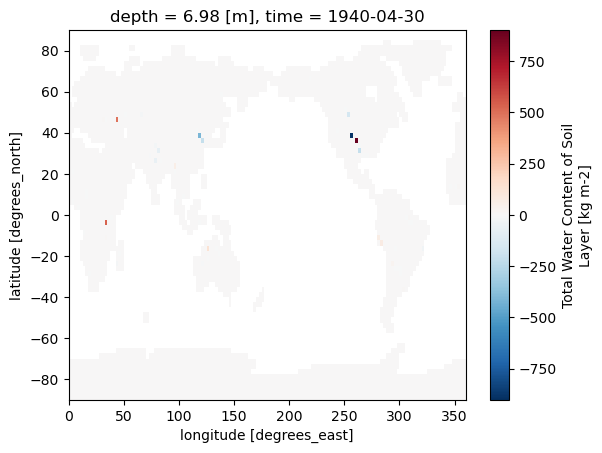

In [10]:
mrsol_pruned_ds_for_mean.isel(depth = 4).isel(time = 90).mrsol.plot(x="lon")

In [11]:
tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=1)
pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=1)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=month_idx)

input_ds_for_mean = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")

tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=2)
pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=2)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=month_idx)

input_ds_for_var = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")

tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=3)
pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=3)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=month_idx)

input_ds_for_test = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")


### Mask and Stack Data

In [12]:
mrsol_masked_ds_for_mean, chunk_mask, detail_mask_mean = model.mask.mask_nonpositiv_height_chunks(mrsol_pruned_ds_for_mean.drop_vars("depth_bnds"))
input_masked_ds_for_mean = model.mask.mask_mask(input_ds_for_mean,chunk_mask)

mrsol_masked_ds_for_var , chunk_mask_var, detail_mask_mean = model.mask.mask_nonpositiv_height_chunks(mrsol_pruned_ds_for_var.drop_vars("depth_bnds"))
input_masked_ds_for_var = model.mask.mask_mask(input_ds_for_var,chunk_mask)

mrsol_masked_ds_for_test, chunk_mask_test, detail_mask_mean= model.mask.mask_nonpositiv_height_chunks(mrsol_pruned_ds_for_test.drop_vars("depth_bnds"))
input_masked_ds_for_test = model.mask.mask_mask(input_ds_for_test,chunk_mask)

mrsol_maximas_masked = model.mask.mask_mask(mrsol_maximas,chunk_mask)

In [13]:
#The chunk_mask schould all be the same, this is important that there are no shape problems in the regressions, you can test this with  
#(chunk_mask != chunk_mask_2).sum(),#(chunk_mask != chunk_mask_1).sum(),
#The chunk_mask is used, that the regression can predict a depth.size vector at each gridcell, the masks: detail_mask_mean, detail_mask_var and detail_mask_test are later used to determan which points are real predictions and witch where just placeholders to let the regression run smoothly.

In [14]:
mrsol_stack_ds_for_mean = mesmer.grid.stack_lat_lon(mrsol_masked_ds_for_mean)
mrsol_stack_ds_for_var = mesmer.grid.stack_lat_lon(mrsol_masked_ds_for_var)
mrsol_stack_ds_for_test = mesmer.grid.stack_lat_lon(mrsol_masked_ds_for_test)
input_stack_ds_for_mean = mesmer.grid.stack_lat_lon(input_masked_ds_for_mean)
input_stack_ds_for_var = mesmer.grid.stack_lat_lon(input_masked_ds_for_var)
input_stack_ds_for_test = mesmer.grid.stack_lat_lon(input_masked_ds_for_test)
mrsol_maximas_stack = mesmer.grid.stack_lat_lon(mrsol_maximas_masked)

### Transform Data

In [15]:
#Normierung, da Betaverteilung zwischen 0 und 1 gefittet wird (für Betaverteilung sollte die Transformation vor dro vars depth bnds, mask und stack sitzen)
#porosität von 0.35 bis 0.6 annehmen
#schauen ob es Modelle hat mit ähnlicher datenstruktur aber mit porösität?

In [16]:
mrsol_t_for_mean = model.transform.none_Transform_ds(mrsol_stack_ds_for_mean)
mrsol_t_for_var = model.transform.none_Transform_ds(mrsol_stack_ds_for_var)
mrsol_t_for_test = model.transform.none_Transform_ds(mrsol_stack_ds_for_test)

### Linear Regression of the mean

In [17]:
mean_predictors = input_stack_ds_for_mean
mean_target_da = mrsol_t_for_mean.mrsol

In [18]:
LinReg_mean = model.stats._parallel_linear_regression.ParLinearRegression()

In [19]:
LinReg_mean.fit(predictors=mean_predictors, target=mean_target_da,location_dim="gridcell", regr_dim="time")

In [20]:
#LinReg_mean.params

### Compute Residuals for the variance

Hier wäre die meinung einen neuen Run zu verwenden, die frage ist ob sich die variance durch das fehlen des runs zu tief ausfällt. Overfitting korrektur mit 1/(1-param/n_samples)^2? (SPäter probieren)

In [21]:
var_predictors = input_stack_ds_for_var
var_target_ds = mrsol_t_for_var

In [22]:
residuals_t = LinReg_mean.residuals(var_predictors, var_target_ds)

In [23]:
residuals_t

<xarray.Dataset> Size: 20MB
Dimensions:    (depth: 5, time: 165, gridcell: 2949)
Coordinates:
  * depth      (depth) float64 40B 0.03 0.19 0.78 2.68 6.98
  * time       (time) datetime64[ns] 1kB 1850-04-30 1851-04-30 ... 2014-04-30
    lat        (gridcell) float64 24kB -56.25 -56.25 -56.25 ... 81.25 81.25
    lon        (gridcell) float64 24kB 288.8 291.2 293.8 ... 293.8 296.2 298.8
    height     float64 8B 2.0
Dimensions without coordinates: gridcell
Data variables:
    residuals  (time, depth, gridcell) float64 19MB -0.02459 ... 2.711e-19

### Linear Regression of the Variance

In [24]:
LinReg_variance = model.stats._parallel_linear_regression.ParLinearRegression()

In [25]:
LinReg_variance.fit(predictors=var_predictors, target=(residuals_t.residuals)**2,location_dim="gridcell", regr_dim="time")

### Predictor

In [26]:
LinReg_mean.params

<xarray.Dataset> Size: 401kB
Dimensions:        (gridcell: 2949, depth: 5)
Coordinates:
    lat            (gridcell) float64 24kB -56.25 -56.25 -56.25 ... 81.25 81.25
    lon            (gridcell) float64 24kB 288.8 291.2 293.8 ... 296.2 298.8
  * depth          (depth) float64 40B 0.03 0.19 0.78 2.68 6.98
Dimensions without coordinates: gridcell
Data variables:
    intercept      (gridcell, depth) float64 118kB 0.6192 0.8015 ... 0.0001
    tas            (gridcell, depth) float64 118kB 0.0007189 ... 3.904e-34
    pr             (gridcell, depth) float64 118kB 934.0 29.37 ... -1.499e-28
    fit_intercept  bool 1B True

In [27]:
LinReg_mean, LinReg_variance

(<model.stats._parallel_linear_regression.ParLinearRegression at 0x7efe603092b0>,
 <model.stats._parallel_linear_regression.ParLinearRegression at 0x7efdcbf14e10>)

### Export Prameters

In [28]:
if False:
    model.save.save_params(LinReg_mean.params,LinReg_variance.params,var = "mrsol",scen= "historical", folder = "MPI-ESM1-2-LR/Log_transform", name=f"month_idx= {month_idx}")

In [29]:
#model.shape_data.load_params(var = "mrsol",scen= "historical", folder = "MPI-ESM1-2-LR/Log_transform")

### Example Emulation

In [30]:
test_predictors = input_stack_ds_for_test
test_target_ds_t = mrsol_t_for_test.transpose("gridcell","time", "depth")

In [31]:
test_mean_prediction_stacked = LinReg_mean.predict(test_predictors).transpose("gridcell","time", "depth")

In [32]:
test_var_prediction_stacked = LinReg_variance.predict(test_predictors).clip(min = 1e-32).transpose("gridcell","time", "depth")

### quantiles

In [33]:
#temp
importlib.reload(model_analysis.crps_score);

In [34]:
mean = test_mean_prediction_stacked.copy(deep=True)
var = test_var_prediction_stacked.copy(deep=True)

#todo precision parameter in guter Quelle finden
precision = (mean*(1-mean))/var-1

test_alpha_prediction_stacked = mean*precision
test_beta_prediction_stacked = (1-mean)*precision

In [35]:
maximas = mrsol_maximas_stack.drop_vars("depth_bnds").transpose("gridcell","depth")


In [36]:
#test_beta_prediction_stacked.isel(depth=slice(0,2)).prediction

scheinbar wächst die laufzeit in der ensemble_size mehr als linear, sieht schlimmer als quadratisch aus:(

5->0.5s

10->1.3s

20->4.2s

40->15s

80->1min 54s

In [37]:
quantile_beta = beta.cdf(test_target_ds_t.isel(depth=slice(0,1)).mrsol, a=test_alpha_prediction_stacked.isel(depth=slice(0,1)).prediction,b=test_beta_prediction_stacked.isel(depth=slice(0,1)).prediction)

In [38]:
xr_quantile_beta = xr.ones_like(test_target_ds_t.isel(depth=slice(0,1)))
xr_quantile_beta["mrsol"] = xr.DataArray(quantile_beta,dims=["gridcell","time","depth"])

In [39]:
quantile_arranged = mesmer.grid.unstack_lat_lon_and_align(xr_quantile_beta,mrsol_masked_ds_for_mean.isel(depth=slice(0,1)))


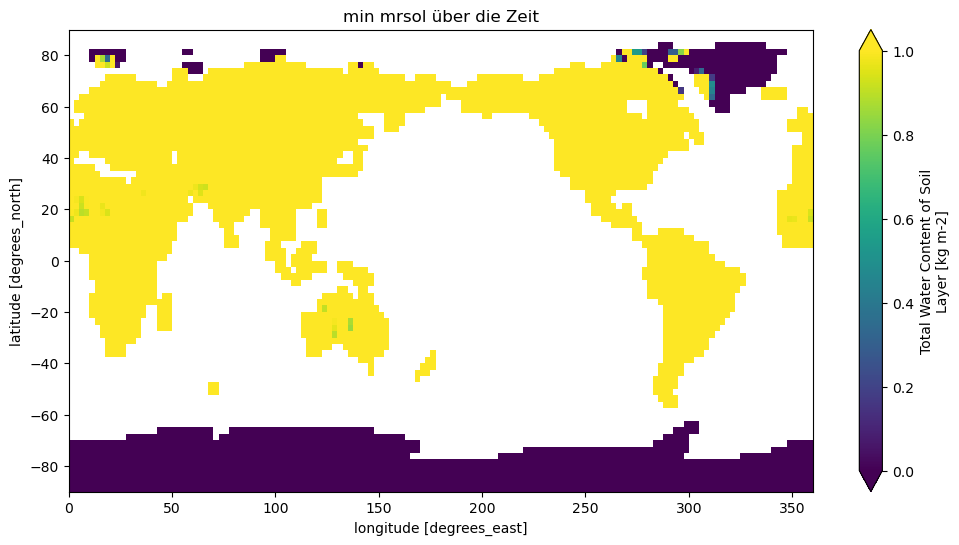

In [40]:
min = mrsol_ds_for_test["mrsol"].min("time").isel(depth=0).squeeze()
plt.figure(figsize=(12, 6))
min.plot(vmin=0, vmax=1)
plt.title("min mrsol über die Zeit")
plt.show()

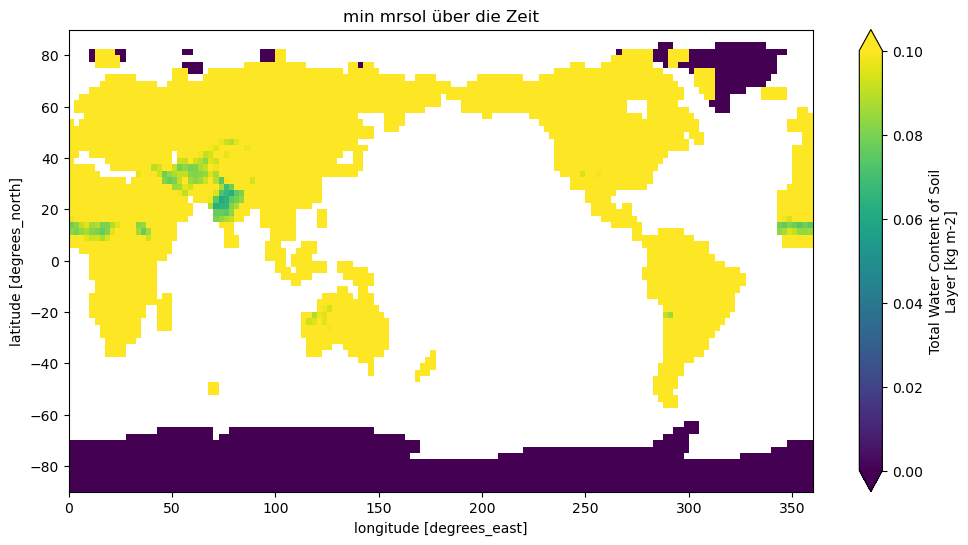

In [41]:
min = mrsol_relative_ds_for_test["mrsol"].min("time").isel(depth=0).squeeze()
plt.figure(figsize=(12, 6))
min.plot(vmin=0, vmax=0.1)
plt.title("min mrsol über die Zeit")
plt.show()

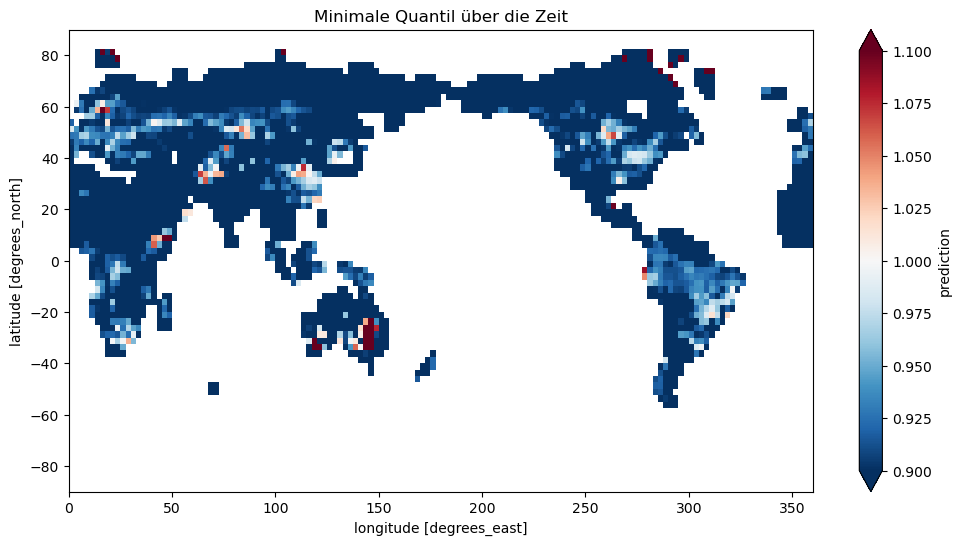

In [42]:
max_mean = mesmer.grid.unstack_lat_lon_and_align(test_mean_prediction_stacked,mrsol_masked_ds_for_mean.isel(depth=slice(0,1)))
max_mean = max_mean["prediction"].max("time").isel(depth=0).squeeze()
plt.figure(figsize=(12, 6))
max_mean.plot(cmap="RdBu_r",vmin=0.9, vmax=1.1)
plt.title("Minimale Quantil über die Zeit")
plt.show()


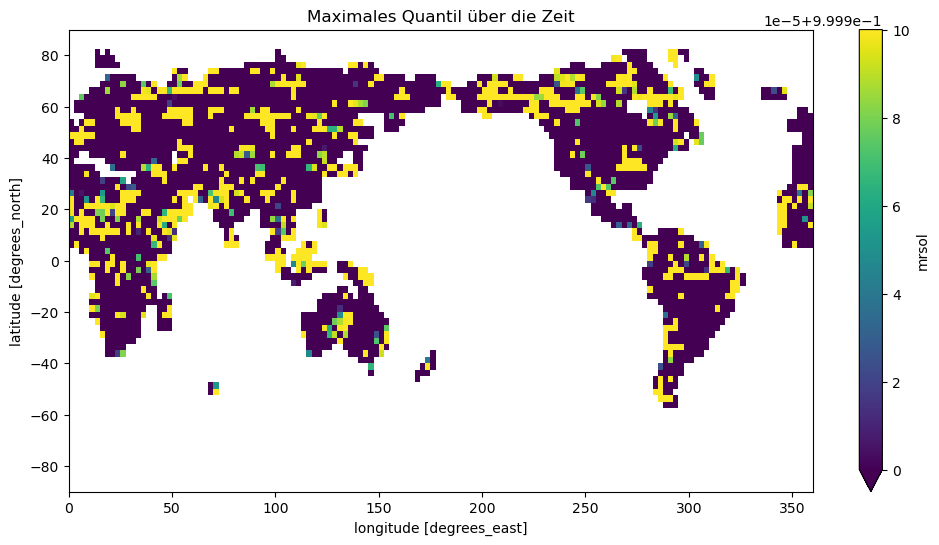

In [43]:
max_quantile = quantile_arranged["mrsol"].max("time").squeeze()
plt.figure(figsize=(12, 6))
max_quantile.plot(vmin=0.9999, vmax=1.0)
plt.title("Maximales Quantil über die Zeit")
plt.show()

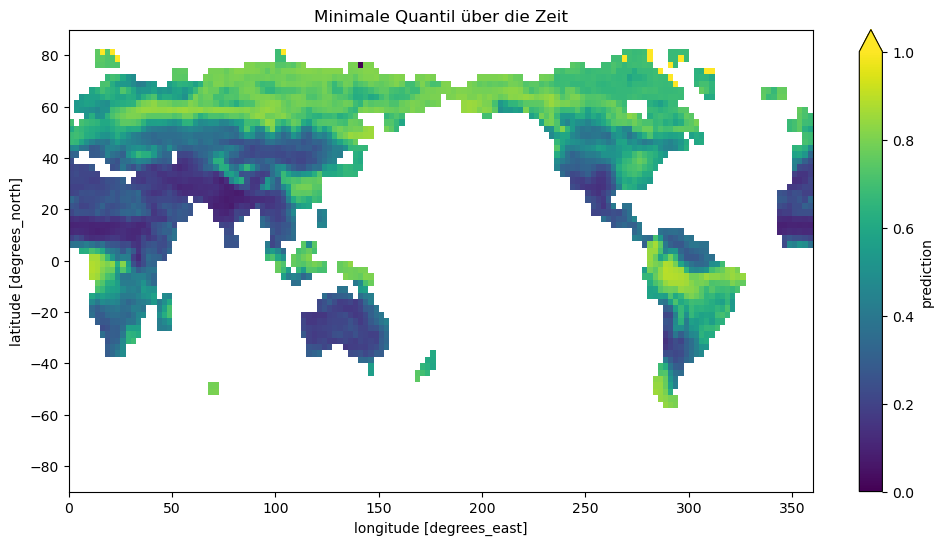

In [44]:
min_mean = mesmer.grid.unstack_lat_lon_and_align(test_mean_prediction_stacked,mrsol_masked_ds_for_mean.isel(depth=slice(0,1)))
min_mean = min_mean["prediction"].min("time").isel(depth=0).squeeze()
plt.figure(figsize=(12, 6))
min_mean.plot(vmin=0, vmax=1)
plt.title("Minimale Quantil über die Zeit")
plt.show()


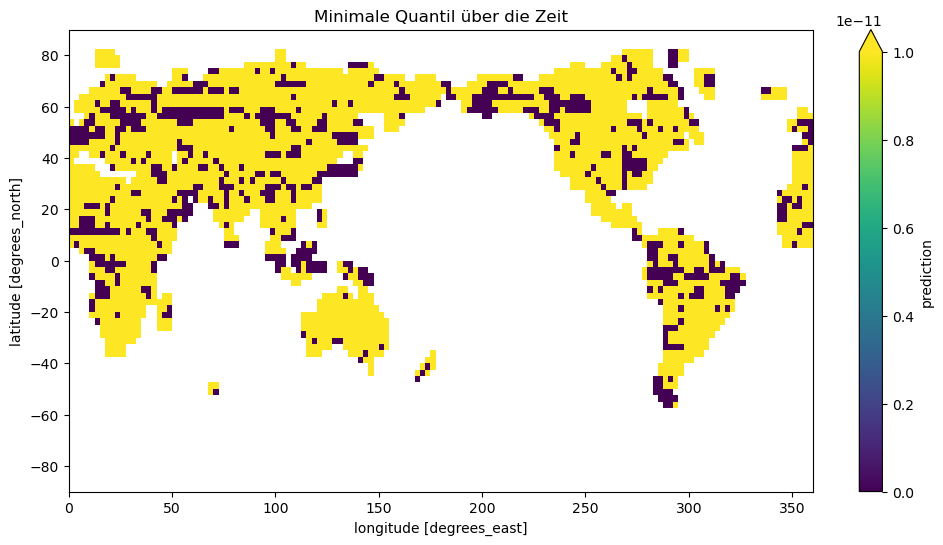

In [45]:
min_var = mesmer.grid.unstack_lat_lon_and_align(test_var_prediction_stacked,mrsol_masked_ds_for_mean.isel(depth=slice(0,1)))
min_var = min_var["prediction"].min("time").isel(depth=0).squeeze()
plt.figure(figsize=(12, 6))
min_var.plot(vmin=0, vmax=0.00000000001)
plt.title("Minimale Quantil über die Zeit")
plt.show()


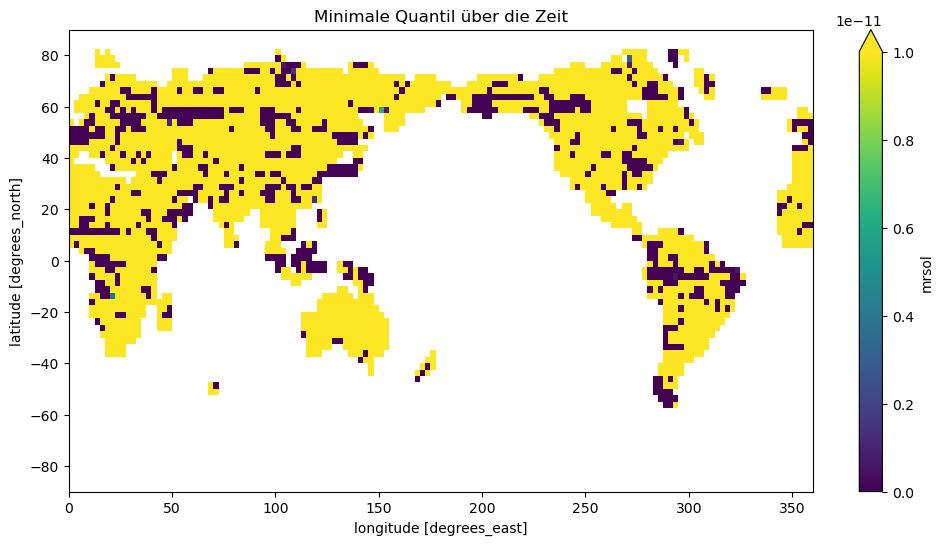

In [46]:
min_quantile = quantile_arranged["mrsol"].min("time").squeeze()
plt.figure(figsize=(12, 6))
min_quantile.plot(vmin=0, vmax=0.00000000001)
plt.title("Minimale Quantil über die Zeit")
plt.show()

Vergleich von umgekehrter run_verwendung zeigt, dass 1.0 qunatile vermutlich nicht aufgrund von unterschiedlichen Maximas entstehen sonder aufgrund von linearer regression die grossen mean schätzt

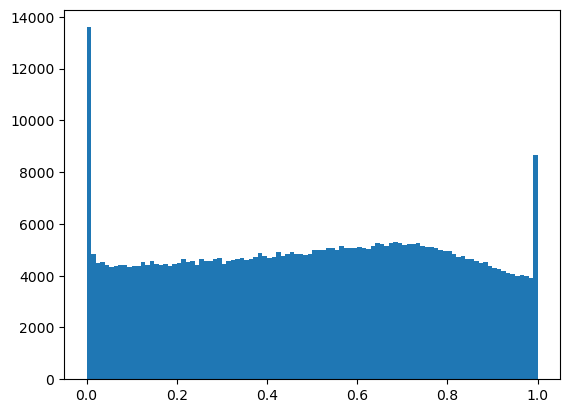

In [47]:
plt.hist(quantile_beta.reshape(-1), bins = 100)
plt.show()

In [101]:
xr_quantile_beta
input_stack_ds_for_mean=input_stack_ds_for_mean.transpose("gridcell","time")



num_quantiles = 7
quantiles = np.linspace(0, 1, num_quantiles + 1)


tas_edges = input_stack_ds_for_mean["tas"].quantile(
    quantiles,
    dim="time",
    skipna=True,
)
pr_edges = input_stack_ds_for_mean["pr"].quantile(
    quantiles,
    dim="time",
    skipna=True,
)

#input_stack_ds_for_mean["tas"]

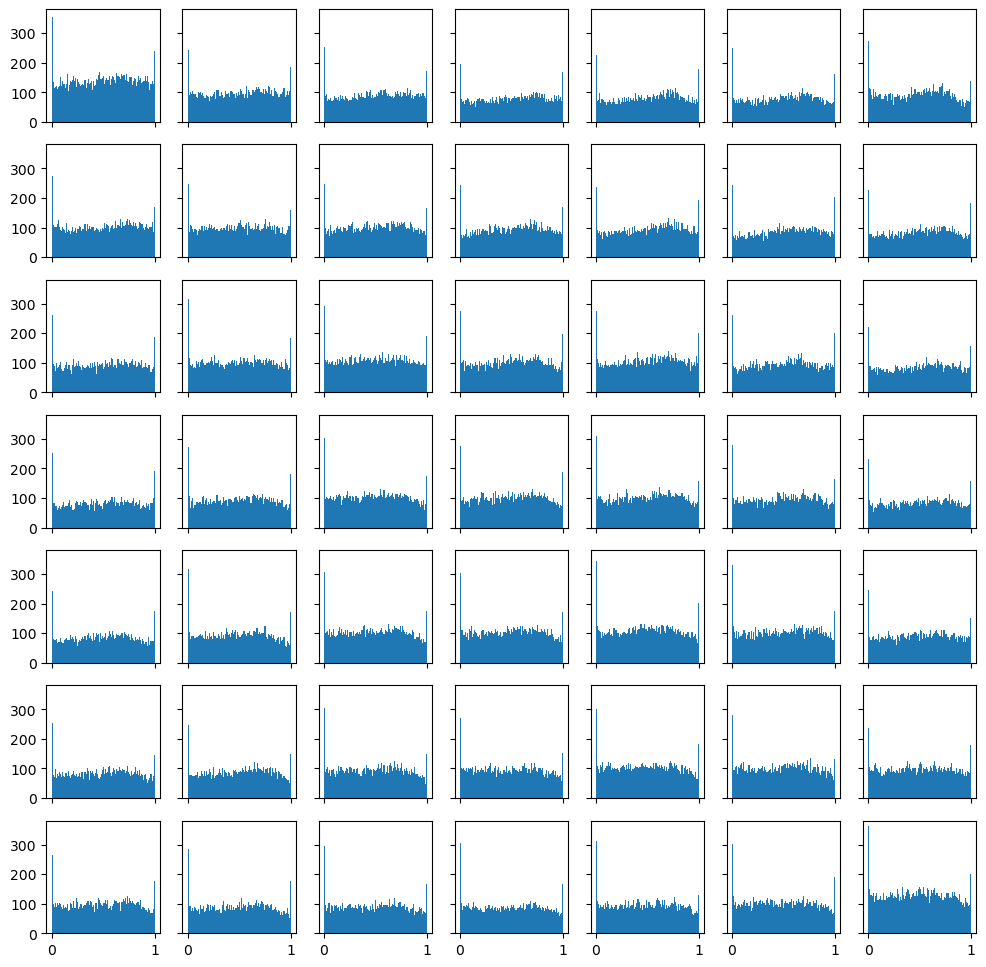

In [102]:
fig, axes = plt.subplots(
        num_quantiles,
        num_quantiles,
        figsize=(12, 12),
        sharex=True,
        sharey=True

    )

for tas_idx in range(num_quantiles):
    for pr_idx in range(num_quantiles):
        mask = (
                (input_stack_ds_for_mean["tas"] >= tas_edges[tas_idx]) &
                (input_stack_ds_for_mean["tas"] < tas_edges[tas_idx+1]) &
                (input_stack_ds_for_mean["pr"] >= pr_edges[pr_idx]) &
                (input_stack_ds_for_mean["pr"] < pr_edges[pr_idx+1])
            )

        bin_quantiles = xr_quantile_beta.mrsol.where(mask).values.flatten()
        bin_quantiles = bin_quantiles[np.isfinite(bin_quantiles)]
        axes[num_quantiles-tas_idx-1,pr_idx].hist(bin_quantiles.reshape(-1), bins = 100)
        

#xr_quantile_beta
#quantile_beta
#bin_quantiles

In [49]:
crps_score_stacked, space_crps_score_stacked = model_analysis.crps_score.crps_beta_ensemble_score(test_alpha_prediction_stacked.isel(depth=slice(0,3)).clip(min=1e-32), test_beta_prediction_stacked.isel(depth=slice(0,3)).clip(min=1e-32),test_target_ds_t.isel(depth=slice(0,3)),transformation="rel",mrsol_maximas=maximas,ensemble_size=15)

for both of the scors we can calculate a crpss score against the time constant mean, for the score of the backtransposed data, we need to make a non-transposed target.

In [50]:

test_target_ds = test_target_ds_t.copy(deep=True) 
test_target_ds["mrsol"] = test_target_ds_t["mrsol"] * maximas["mrsol"]


In [51]:
scores_stacked = model_analysis.crps_score.add_crpss_against_mean_ensemble_score(crps_score_stacked,test_target_ds) 

In [52]:
space_scores_stacked = model_analysis.crps_score.add_crpss_against_mean_ensemble_score(space_crps_score_stacked,test_target_ds_t) 

To visualize the results we bring it back to the lat lon grid form. Ausserdem entnehmen wir die Stellen wieder, die mit threshholds aufgefüllt wurden

In [53]:
scores = mesmer.grid.unstack_lat_lon_and_align(scores_stacked,mrsol_masked_ds_for_mean.isel(depth=slice(0,2)))
space_scores = mesmer.grid.unstack_lat_lon_and_align(space_scores_stacked,mrsol_masked_ds_for_mean.isel(depth=slice(0,2)))

In [54]:
scores = model.mask.mask_mask(scores,detail_mask_mean, "lon","lat", "depth")
space_scores = model.mask.mask_mask(space_scores,detail_mask_mean, "lon","lat", "depth")

Globale Score übersicht

Text(0.5, 1.0, 'crpss_score against const mean')

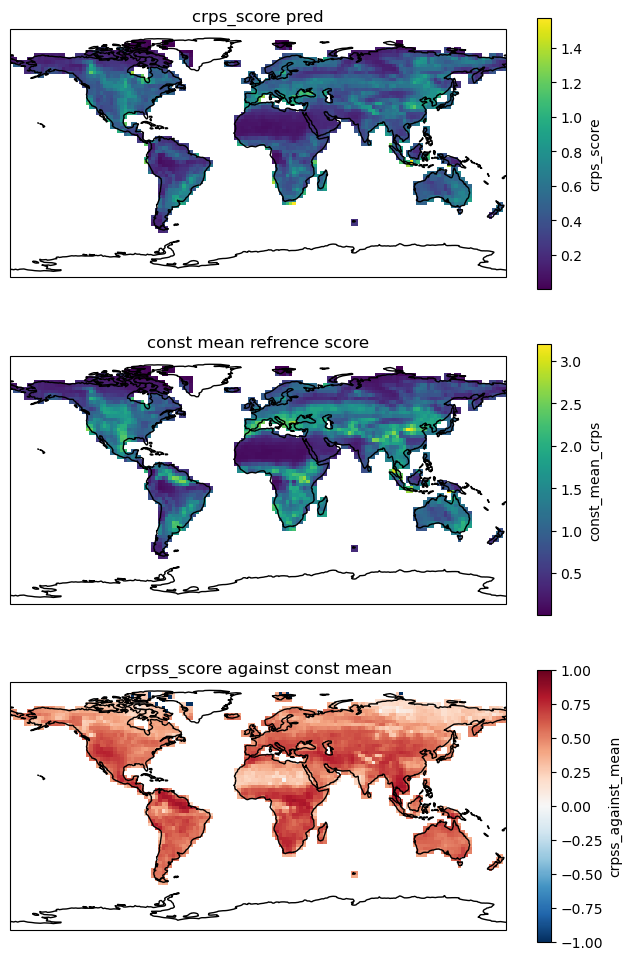

In [55]:
fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=3,
    ncols=1,
    figsize=(8, 12)
)
depth = 0

da = scores.isel(depth=depth).mean("time").crps_score.clip(max=2)
da.plot(ax=ax[0])
ax[0].coastlines()
ax[0].set_title("crps_score pred")

da = scores.isel(depth=depth).mean("time").const_mean_crps
da.plot(ax=ax[1])
ax[1].coastlines()
ax[1].set_title("const mean refrence score")

da = scores.isel(depth=depth).mean("time").crpss_against_mean.clip(min=-1)
da.plot(ax=ax[2])
ax[2].coastlines()
ax[2].set_title("crpss_score against const mean")



Text(0.5, 1.0, 'space_crpss_score against const mean')

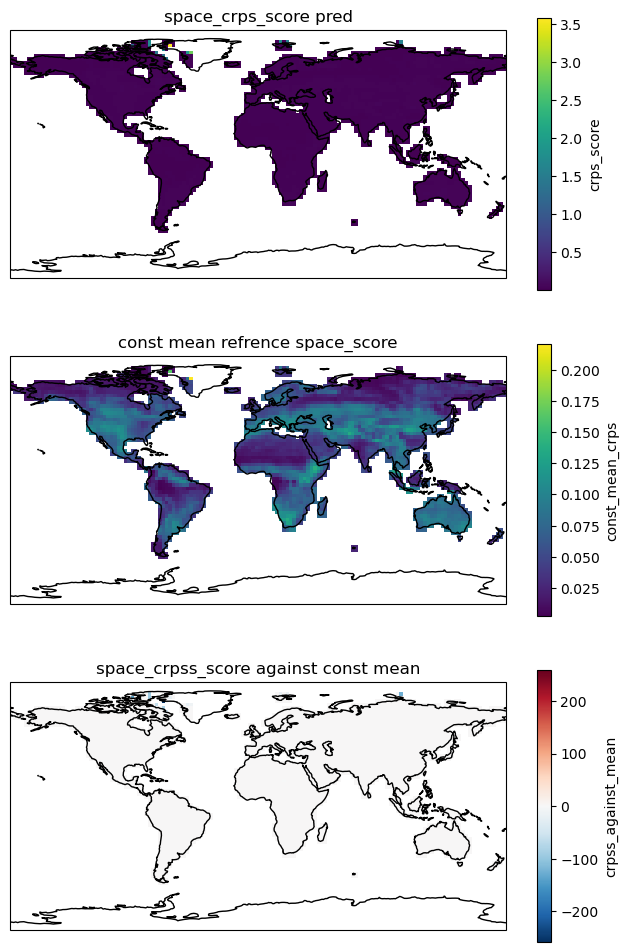

In [56]:
fig_global_space_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=3,
    ncols=1,
    figsize=(8, 12)
)

da = space_scores.isel(depth=0).mean("time").crps_score
da.plot(ax=ax[0])
ax[0].coastlines()
ax[0].set_title("space_crps_score pred")

da = space_scores.isel(depth=0).mean("time").const_mean_crps
da.plot(ax=ax[1])
ax[1].coastlines()
ax[1].set_title("const mean refrence space_score")

da = space_scores.isel(depth=0).mean("time").crpss_against_mean
da.plot(ax=ax[2])
ax[2].coastlines()
ax[2].set_title("space_crpss_score against const mean")



Locale Zeit reihe

In [57]:
#Amazonas  ca. 3° S, 65° W

In [58]:
#scores.sel(lat= -3, lon = 295, method="nearest").isel(depth = 0).to_array().plot.line(hue="variable", x = "time");

In [59]:
#irgendwo in Russland

In [60]:
#scores.sel(lat= 60, lon = 100, method="nearest").isel(depth = 0).to_array().plot.line(hue="variable", x = "time");

### Save results

In [61]:
if safe:
    model.save.save_crps_scores(space_scores, var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/Beta_dist", name=f"approx_mon_emp11_month_idx = {month_idx}",name_postfix="")
    model.save.save_crps_scores(scores, var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/Beta_dist",name=f"approx_mon_emp11_month_idx = {month_idx}", name_postfix="back_transformed")
    model.save.save_plot(fig_global_crpss, var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/Beta_dist", name = f"fig_global_crpss_clipped_month_idx = {month_idx}_approx_mon_emp11")
    model.save.save_plot(fig_global_space_crpss, var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/Beta_dist", name = f"fig_global_space_crpss__month_idx = {month_idx}_approx_mon_emp11")